In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
# sys.path.append('"nt_s_drive

In [2]:
import pandas as pd
import os
import sys
import pymc as pm
import pymc_bart as pmb
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold

import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from MIMICUtil import *


In [3]:
columns = ['chart_seizure_duration_Status',
 'chart_cervical_collar_status_On',
 'med_sodium_bicarbonate',
 'input_sodium_bicarbonate_8.4%',
 'med_calcium_acetate',
 'input_calcium_gluconate',
 'med_miconazole_2%_cream',
 'chart_first_creatinine_(serum)',
 'chart_first_d-dimer',
 'output_first_d-dimer',
 'chart_first_fio2_(ch)',
 'chart_first_fio2_(ecmo)',
 'chart_first_glucose_(serum)',
 'chart_first_glucose_(whole_blood)',
 'chart_first_hemoglobin',
 'chart_problem_list_.H/O anemia, hemolytic',
 'med_calcium_acetate',
 'input_po_intake',
 'input_packed_red_blood_cells',
 'chart_first_hematocrit_(whole_blood_-_calc)',
 'chart_first_lipase',
 'output_first_lipase',
 'chart_first_magnesium',
 'input_magnesium_sulfate',
 'chart_first_peco2',
 'chart_first_etco2',
 'chart_first_peco2',
 'chart_first_svo2',
 'chart_first_gi_ph',
 'chart_first_ph_(venous)',
 'lab_first_platelet_count',
 'chart_first_absolute_count_-_eos',
 'input_po_intake',
 'lab_first_potassium_(serum)',
 'chart_first_total_protein',
 'output_first_total_protein',
 'input_heparin_sodium',
 'med_nitroprusside_sodium',
 'chart_lle_temp_Warm',
 'chart_rue_temp_Cold',
 'lab_first_prothrombin_time',
 'output_first_alt',
 'lab_first_troponin-t',
 'input_rocuronium',
 'chart_first_svo2',
 'chart_first_peco2',
 'lab_first_troponin-t',
 'input_tirofiban_(aggrastat)',
 'chart_first_arterial_blood_pressure_alarm_-_high',
 'chart_first_arterial_blood_pressure_mean',
 'chart_performance_level_Auto',
 'chart_performance_level_P2',
 'chart_performance_level_(r)_P6',
 'chart_performance_level_Auto',
 'chart_daily_wake_up_No, at goal RASS',
 'death_at_disch',
 'death_at_disch',
 'med_oxycodone_(immediate_release)_',
 'age',
 'subject_id',
 'chart_speech_Normal',
 'chart_lue_color_Normal',
 'chart_heart_rhythm_2nd AV M2 (Second degree AV Block - Mobitz 2) ',
 'lab_first_ldl_measured',
 'lab_first_digoxin',
 'lab_first_ldl_measured',
 'lab_first_digoxin',
 'lab_first_ldl_measured',
 'chart_heart_rhythm_3rd AV (Complete Heart Block) ',
 'chart_art_bubble_on_(ch)',
 'chart_urine_appearance_Cloudy',
 'chart_art_bubble_on_(ch)',
 'med_sarna_lotion',
 'chart_first_impella_catheter_position',
 'chart_lue_temp_Warm',
 'med_fentanyl_citrate',
 'chart_first_qtc',
 'output_first_qtc',
 'chart_temporary_ventricular_sens_Yes',
 'chart_temporary_ventricular_capture_Yes',
 'chart_problem_list_Ventricular tachycardia, sustained',
 'chart_first_vd/vt_ratio',
 'med_vasopressin',
 'chart_st_segment_monitoring_on',
 'chart_st_segment_monitoring_on',
 'med_sarna_lotion',
 'chart_problem_list_Tachycardia, Other',
 'chart_heart_rhythm_ST (Sinus Tachycardia) ',
 'med_alteplase',
 'med_norepinephrine',
 'chart_heart_rhythm_V Paced',
 'chart_problem_list_Cardiac arrest',
 'chart_post-op_care_ncp_-_interventions_Assess surgical wounds and drains',
 'med_ursodiol',
 'chart_seizure_duration_Status',
 'med_sarna_lotion',
 'input_diltiazem',
 'chart_skin_condition_Diaphoretic',
 'chart_angio_site_#_1_R Femoral',
 'chart_first_ph_(venous)',
 'med_linezolid',
 'med_aspirin_ec',
 'med_sarna_lotion',
 'chart_impaired_fluid_balance_ncp_-_interventions_Monitoring electrolytes / renal function',
 'chart_first_hemoglobin',
 'chart_stroke_ncp_-_type_Hemorrhagic',
 'chart_first_intra_cranial_pressure',
 'chart_first_intra_cranial_pressure_#2',
 'chart_problem_list_Pulmonary edema',
 'chart_first_pulmonary_artery_pressure_mean',
 'med_tamsulosin',
 'med_insulin',
 'med_epinephrine_1:1000',
 'med_epinephrine',
 'med_epinephrine_1:1000',
 'med_epinephrine',
 'med_epinephrine_1:1000',
 'med_epinephrine',
 'age',
 'gender',
 'lab_first_platelet_count',
 'chart_pain_management_Repositioned',
 'med_vasopressin',
 'input_vasopressin',
 'med_sarna_lotion',
 'med_mannitol',
 'chart_first_arterial_blood_pressure_alarm_-_high',
 'chart_problem_list_Cerebrovascular disease, other',
 'chart_past_medical_history_COPD',
 'chart_cv_-_past_medical_history_CAD',
 'med_sodium_bicarbonate',
 'input_sodium_bicarbonate_8.4%',
 'med_sodium_bicarbonate',
 'input_sodium_bicarbonate_8.4%',
 'chart_first_bis_index_range',
 'chart_first_cardiac_index_(ci_nicom)',
 'chart_education_topic_Cardioversion',
 'chart_problem_list_Shock, cardiogenic',
 'chart_problem_list_Cardiac arrest',
 'chart_cardiac_assist_cannula_site_appear_WNL',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_gag_reflex_Intact',
 'chart_gag_reflex_Absent',
 'chart_incision_#1-_location_Tracheostomy',
 'chart_incision_#1-_location_Chin',
 'med_amiodarone',
 'input_amiodarone',
 'med_amiodarone',
 'input_amiodarone',
 'chart_corneal_reflex_left_Intact',
 'chart_corneal_reflex_left_Absent',
 'chart_daily_wake_up_deferred_Neuromusc Block',
 'chart_neuro_drain_#1_level_15 cm',
 'input_lidocaine',
 'input_amiodarone',
 'input_lidocaine',
 'med_midodrine',
 'chart_heart_rhythm_AF (Atrial Fibrillation)',
 'chart_problem_list_.H/O atrial fibrillation (Afib)',
 'chart_heart_rhythm_AF (Atrial Fibrillation)',
 'chart_problem_list_.H/O atrial fibrillation (Afib)',
 'med_nafcillin',
 'chart_first_heart_rate',
 'chart_first_fio2_(ch)',
 'chart_first_fio2_(ecmo)',
 'chart_first_respiratory_rate',
 'chart_first_respiratory_rate_(set)',
 'chart_20_g_infiltration_scale_Grade 0',
 'chart_20_g_infiltration_scale_Grade 2',
 'chart_goal_richmond-ras_scale_ No eye contact',
 'chart_20_g_infiltration_scale_Grade 0',
 'chart_cv_-_past_medical_history_Hypertension',
 'chart_problem_list_.H/O abdominal compartment syndrome / Intraabdominal Hypertension (IAH, ACS)',
 'hypothermia',
 'med_nephrocaps',
 'chart_pain_level_Unable to Score',
 'chart_pain_level_response_Unable to Score',
 'chart_circuit_configuration_(ch)_VA',
 'chart_par-circulation_BP +/- 20% of pre-anesthesthetic level',
 'chart_is_the_spokesperson_the_health_care_proxy',
 'chart_20_gauge_placed_in_the_field',
 'chart_problem_list_Cardiac arrest',
 'chart_ett_location_Oral-R',
 'chart_first_blood_flow_(ml/min)',
 'chart_first_flow_(ch)',
 'chart_pain_level_Unable to Score',
 'chart_pain_level_response_Unable to Score',
 'med_morphine_infusion_–_comfort_care_guidelines',
 'med_norepinephrine',
 'chart_motor_l_leg_Localizes',
 'chart_motor_l_arm_Localizes',
 'chart_problem_list_Myocardial infarction, acute (AMI, STEMI, NSTEMI)',
 'underlying_cardiac_condition',
 'chart_first_flow_(ch)',
 'chart_first_flow_(ecmo)',
 'med_norepinephrine',
 'input_norepinephrine',
 'chart_first_heart_rate_alarm_-_low',
 'chart_first_heart_rate_alarm_-_high',
 'chart_svo2_sqi_1',
 'chart_first_svo2',
 'chart_eye_care',
 'chart_gcs_-_eye_opening_To Pain',
 'chart_first_lipase',
 'chart_first_manual_blood_pressure_diastolic_left',
 'input_diazepam_(valium)',
 'input_lorazepam_(ativan)',
 'chart_first_lipase',
 'chart_past_medical_history_COPD',
 'input_famotidine_(pepcid)',
 'lab_first_brain_natiuretic_peptide_(bnp)',
 'chart_first_daily_weight',
 'chart_first_feeding_weight',
 'chart_problem_list_Pulmonary edema',
 'chart_rul_lung_sounds_Diminished',
 'chart_pupil_size_right_Pinpoint',
 'chart_pupil_size_right_Fully Dilated',
 'chart_pupil_response_right_Non-reactive',
 'chart_pupil_response_left_Non-reactive',
 'chart_pupil_size_left_Pinpoint',
 'chart_pupil_size_left_5mm',
 'chart_pupil_response_left_Non-reactive',
 'chart_pupil_response_right_Non-reactive',
 'chart_gag_reflex_Intact',
 'chart_gag_reflex_Absent',
 'chart_gag_reflex_Intact',
 'chart_gag_reflex_Absent',
 'chart_gag_reflex_Absent',
 'chart_gag_reflex_Intact',
 'chart_heart_rhythm_SR (Sinus Rhythm)',
 'chart_heart_rhythm_ST (Sinus Tachycardia) ',
 'chart_daily_wake_up_Yes, sedation adjusted or stopped',
 'chart_humidification_Active',
 'med_alteplase',
 'med_aspirin_ec',
 'chart_first_spo2_desat_limit',
 'output_first_spo2_desat_limit',
 'chart_problem_list_.H/O tobacco\xa0use, current',
 'chart_tobacco_use_history_Never used',
 'chart_first_height',
 'chart_first_height_(cm)',
 'chart_problem_list_Cardiac arrest',
 'chart_first_access_pressure',
 'chart_problem_list_Cardiac arrest',
 'chart_impaired_skin_cleanse_#6_Foam Cleanser',
 'chart_rue_temp_Warm',
 'chart_lle_temp_Cold',
 'chart_gcs_-_verbal_response_Oriented',
 'chart_gcs_-_verbal_response_No Response',
 'chart_first_spont_vt',
 'chart_first_vd/vt_ratio',
 'chart_emotional_/_physical_/_sexual_harm_by_partner_or_close_relation',
 'age',
 'chart_problem_list_Shock, cardiogenic',
 'chart_education_topic_Cardioversion',
 'med_sarna_lotion',
 'input_solution',
 'med_heparin',
 'chart_lle_temp_Cool',
 'chart_neuro_drain_#1_level_15 cm',
 'chart_neuro_drain_landmark_Tragus',
 'chart_circuit_configuration_(ch)_VA',
 'chart_problem_list_Renal failure, acute (Acute renal failure, ARF, AKI)',
 'chart_first_respiratory_rate',
 'chart_respiratory_effort_Normal',
 'death_at_disch',
 'last_mGCS',
 'death_at_disch',
 'last_mGCS',
 'death_at_disch',
 'last_mGCS',
 'subject_id',
 'chart_patient/family_informed_-----',
 'chart_back_care',
 'med_heparin',
 'chart_angio_site_#_1_R Femoral',
 'chart_angio_dressing_#_1_Bandaid',
 'chart_angio_dressing_#_1_Bandaid',
 'chart_angio_dressing_#_2_Bandaid',
 'chart_intra_aortic_balloon_pump_setting_1:2',
 'chart_intra_aortic_ballon_pump_setting_1:1',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'chart_alarms_on',
 'chart_slope_On',
 'med_nephrocaps',
 'chart_problem_list_Shock, cardiogenic',
 'chart_problem_list_Shock, cardiogenic',
 'chart_first_temporary_av_interval',
 'chart_angio_dressing_#_1_Bandaid',
 'chart_angio_dressing_#_2_Bandaid',
 'med_amiodarone',
 'chart_back_care',
 'hypothermia',
 'chart_impaired_tissue_perfusion_ncp_-_interventions_Therapeutic temperature management',
 'chart_stool_consistency_Loose',
 'lab_first_prothrombin_time',
 'chart_incision_#1-_treatment_Ace Wrap',
 'chart_incision_#1-_treatment_Xeroform',
 'hypothermia',
 'bmi',
 'height_cm',
 'weight_kg',
 'first_mGCS',
 'long_title_atrial_fibrillation',
 'long_title_chronic_atrial_fibrillation',
 'long_title_paroxysmal_atrial_fibrillation',
 'long_title_unspecified_atrial_fibrillation',
 'long_title_ventricular_fibrillation']


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
# death_at_disch hypothermia 
def getTrainTestFunctions(aPredictedColumn = 'LastMGCSPositive', aTreatmentColumn = 'hypothermia', aTestSize = 0.3, aTreatmentSplit = False, aDropColumns = [], aSkipTemp = True):
    myPredictorsDf = pd.read_csv('MIMIC_Predictors.csv')

    # top_corr = pd.read_csv('top_correlations.csv')
    # columns_to_drop = top_corr[top_corr['hypothermia'].abs() > 0.7]['Unnamed: 0'].tolist()
    columns_to_drop= []
    # Preprocessing
    myFilter = (myPredictorsDf['first_mGCS_time'] != myPredictorsDf['last_mGCS_time']) 
    myPredictorsDf.loc[myPredictorsDf['death_at_disch'] == 1, 'last_mGCS'] = 1
    myPredictorsDf.loc[myFilter, 'LastMGCSPositive'] = (myPredictorsDf.loc[myFilter, 'last_mGCS'].astype(float) == 6).astype(int)

    myBinaryColumns = myPredictorsDf.columns[myPredictorsDf.nunique() == 2] 
    myBinaryDf = myPredictorsDf[myBinaryColumns]
    myBinaryDf = myBinaryDf.select_dtypes(exclude=["object"])
    myLowColumns = myBinaryDf.columns[(myBinaryDf.sum() < 15)]
    myPredictorsDf.drop(columns=list(myLowColumns) + aDropColumns, inplace=True)

    myGcs15Fitler = (myPredictorsDf.first_mGCS != 6)

    if (aPredictedColumn == 'LastMGCSPositive'):
        myPredictorsDf = myPredictorsDf[myGcs15Fitler & myFilter & ~myPredictorsDf[aTreatmentColumn].isna()]
    else:
        myPredictorsDf = myPredictorsDf[myGcs15Fitler & ~myPredictorsDf[aPredictedColumn].isna() & ~myPredictorsDf[aTreatmentColumn].isna()]

    myColumns = []
    if (aSkipTemp):
        myColumns = [x for x in myPredictorsDf.columns if 'emp' in x or 'dx_' == x[0:3]]

    # Get output data
    myXValue = myPredictorsDf.drop(columns=columns_to_drop +  myColumns + ['first_mGCS', 'last_mGCS_time', 'first_mGCS_time', 'LastMGCSPositive', 'last_mGCS', 'death_at_disch'])
    myXValue = myXValue
    myXValue = myXValue.select_dtypes(exclude=['object'])
    myYValue = myPredictorsDf[aPredictedColumn]
    myYValue = myYValue.astype(int)

    if (aTreatmentSplit):
        myXValue = myXValue.drop(columns=[aTreatmentColumn])
        X_train, X_test, T_train, T_test, y_train, y_test = train_test_split(myXValue, myPredictorsDf[aTreatmentColumn], myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, T_train, T_test, y_train, y_test
    else:
        X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, y_train, y_test

In [5]:
myTreatmentColumn = 'hypothermia'
myPredictorsDf, X_train, X_test, y_train, y_test = getTrainTestFunctions(aPredictedColumn = 'death_at_disch', 
                                                                         aTreatmentColumn = myTreatmentColumn, aSkipTemp = True) 

In [6]:
def getCovariatePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = PCA(0.99)
        )

def getVariancePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = VarianceThreshold(0.01)
        )
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    myPreprocessor.set_output(transform="pandas")
    myImputer = KNNImputer(n_neighbors=50)
    myImputer.set_output(transform="pandas")
    myBinaryColumns  = ['bin__' + x for x in myBinaryColumns]
    myCovariates = getCovariatePreprocessor(['keep__bin__' + myTreatmentColumn])
    myCovariates.set_output(transform="pandas")
    myVariance = getVariancePreprocessor(['bin__' + myTreatmentColumn])
    myVariance.set_output(transform="pandas")
    return [('preprocessor', myPreprocessor), ('imputer', myImputer)]

In [7]:
# X_train = X_train.loc[:, X_train.isnull().mean() < 0.9]
# X_test = X_test[X_train.columns]

In [8]:
# X_train = X_train.loc[:, X_train.isnull().mean() < 0.9]
# X_test = X_test[X_train.columns]
columns_filter = np.unique([x for x in columns if x in X_train.columns])
X_train = X_train[columns_filter]
X_test = X_test[columns_filter]

In [9]:
myPipeline = Pipeline(getDefaultPipelineSteps(X_train))
X_train_transf = myPipeline.fit_transform(X_train, y_train)
X_test_transf = myPipeline.transform(X_test)
X_train_transf = pd.DataFrame(X_train_transf, columns = myPipeline.get_feature_names_out())
X_test_transf = pd.DataFrame(X_test_transf, columns = myPipeline.get_feature_names_out())

In [10]:

with pm.Model() as model:
    X_shared = pm.Data('X_shared', X_train_transf)
    y_shared = pm.Data('y_shared', y_train)
    u = pmb.BART('u', X = X_shared, Y= y_train, m=50)
    p = 1 / (1 + np.exp(-u))
    y_obs= pm.Bernoulli('y_obs', p=p, observed = y_shared)
    trace = pm.sample(50, return_inferencedata=True)
    # trace = az.from_netcdf('bart_model_tracedc.nc')
# Save trace 
# az.to_netcdf(trace, 'bart_model_tracedc.nc')

Only 50 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.
Multiprocess sampling (4 chains in 4 jobs)
PGBART: [u]


/home/mbranda1/.local/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 50 draw iterations (4_000 + 200 draws total) took 15 seconds.
The number of samples is too small to check convergence reliably.


In [11]:
# import arviz as az
# az.to_netcdf(trace, 'bart_model_tracedc.nc')

In [12]:
with model:
    pm.set_data({'X_shared': X_train_transf, 'y_shared': y_train})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    # Calculate the mean predicted probability
    predicted_probs = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data

threshold = 0.5
predictions = (predicted_probs > threshold).astype(int)
from sklearn.metrics import roc_auc_score, accuracy_score

# Calculate ROC AUC
roc_auc = roc_auc_score(y_train, predicted_probs)

# Calculate accuracy
accuracy = accuracy_score(y_train, predictions)

print(f'ROC AUC: {roc_auc:.2f}')
print(f'Accuracy: {accuracy:.2f}')

Sampling: [y_obs]


/home/mbranda1/.local/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

ROC AUC: 0.86
Accuracy: 0.77


In [13]:
with model:
    pm.set_data({'X_shared': X_test_transf, 'y_shared': y_test})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    predicted_probs = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data

threshold = 0.5
predictions = (predicted_probs > threshold).astype(int)
from sklearn.metrics import roc_auc_score, accuracy_score

# Calculate ROC AUC
roc_auc = roc_auc_score(y_test, predicted_probs)

# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)

print(f'ROC AUC: {roc_auc:.2f}')
print(f'Accuracy: {accuracy:.2f}')

Sampling: [u, y_obs]


/home/mbranda1/.local/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/mbranda1/.local/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

ROC AUC: 0.69
Accuracy: 0.66


(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'MIMIC-IV BART Calibration Plot'}, xlabel='Mean predicted probability', ylabel='Observed event rate'>)

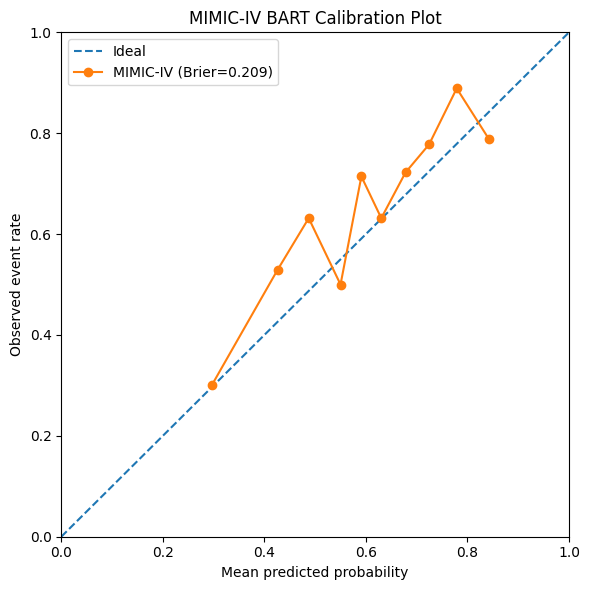

In [14]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

def calibration_intercept_slope(y_true, y_prob, eps=1e-6):
    """
    Compute calibration intercept and slope by regressing outcome on logit(predicted probability).
    Ideal intercept = 0, slope = 1.
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_prob = np.clip(y_prob, eps, 1 - eps)

    logit_p = np.log(y_prob / (1 - y_prob))
    X = sm.add_constant(logit_p)

    fit = sm.Logit(y_true, X).fit(disp=False)

    intercept = fit.params[0]
    slope = fit.params[1]

    return intercept, slope

def calibration_metrics(y_true, y_prob):
    """
    Return a small dict of discrimination + calibration metrics.
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    intercept, slope = calibration_intercept_slope(y_true, y_prob)

    return {
        "n": len(y_true),
        "event_rate": float(np.mean(y_true)),
        "auc": float(roc_auc_score(y_true, y_prob)),
        "brier": float(brier_score_loss(y_true, y_prob)),
        "calibration_intercept": float(intercept),
        "calibration_slope": float(slope),
    }

def plot_calibration_curve_one(y_true, y_prob, title="", n_bins=10, ax=None):
    """
    Reliability diagram / calibration curve.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    frac_pos, mean_pred = calibration_curve(
        y_true,
        y_prob,
        n_bins=n_bins,
        strategy="quantile"
    )

    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.plot(mean_pred, frac_pos, marker="o")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed event rate")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    return ax
def plot_calibration_curve_multi(model_preds, y_true, title="", n_bins=10):
    """
    model_preds: dict like {"XGBoost": probs1, "NN": probs2, "BART": probs3}
    """
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.plot([0, 1], [0, 1], linestyle="--", label="Ideal")

    for model_name, y_prob in model_preds.items():
        frac_pos, mean_pred = calibration_curve(
            y_true,
            y_prob,
            n_bins=n_bins,
            strategy="quantile"
        )
        brier = brier_score_loss(y_true, y_prob)
        ax.plot(mean_pred, frac_pos, marker="o", label=f"{model_name} (Brier={brier:.3f})")

    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed event rate")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()

    plt.tight_layout()
    return fig, ax

def build_calibration_table(results_dict):
    """
    results_dict structure:
    {
        ("eICU", "Neuro", "XGBoost"): (y_true, y_prob),
        ("eICU", "Neuro", "NN"): (y_true, y_prob),
        ...
    }
    """
    rows = []

    for (dataset, outcome, model), (y_true, y_prob) in results_dict.items():
        m = calibration_metrics(y_true, y_prob)
        m.update({
            "dataset": dataset,
            "outcome": outcome,
            "model": model
        })
        rows.append(m)

    df = pd.DataFrame(rows)
    df = df[
        [
            "dataset", "outcome", "model", "n", "event_rate",
            "auc", "brier", "calibration_intercept", "calibration_slope"
        ]
    ].sort_values(["dataset", "outcome", "model"]).reset_index(drop=True)

    return df
# y_pred_prob = model.predict(X_test)[:, 1]

results_dict = {
    ("eICU", "Mortality", "NN"): (y_test, predicted_probs),
    # ...
}

calib_table = build_calibration_table(results_dict)
calib_table.round(3)
plot_calibration_curve_multi({"MIMIC-IV":predicted_probs}, y_test, "MIMIC-IV BART Calibration Plot")

In [16]:
calib_table

,dataset,outcome,model,n,event_rate,auc,brier,calibration_intercept,calibration_slope
0,eICU,Mortality,NN,184,0.641304,0.687339,0.209006,0.22324,0.947963


In [61]:
import numpy as np
from sklearn.metrics import roc_auc_score

def bootstrap_auc_ci(y_true, y_pred_proba, n_bootstraps=1000, ci=95, random_seed=42):
    rng = np.random.RandomState(random_seed)
    n = len(y_true)
    bootstrapped_scores = []
    
    for _ in range(n_bootstraps):
        # Sample with replacement
        indices = rng.choice(np.arange(n), size=n, replace=True)
        if len(np.unique(y_true[indices])) < 2:
            # We need at least one positive and one negative sample
            continue
        score = roc_auc_score(y_true[indices], y_pred_proba[indices])
        bootstrapped_scores.append(score)
    
    sorted_scores = np.sort(bootstrapped_scores)
    lower_bound = np.percentile(sorted_scores, (100 - ci) / 2)
    upper_bound = np.percentile(sorted_scores, 100 - (100 - ci) / 2)
    
    return lower_bound, upper_bound, sorted_scores

# Example usage
# y_true = np.array([...])
# y_pred_proba = np.array([...])

ci_lower, ci_upper, auc_scores = bootstrap_auc_ci(y_test.to_numpy(), predicted_probs)
print(f"95% CI for AUC: [{ci_lower:.3f}, {ci_upper:.3f}]")


95% CI for AUC: [0.635, 0.790]


In [30]:
myXValueModified1 = X_train.copy()
myXValueModified1['Hypothermia'] = 1.0
myXValueModified2 = X_train.copy()
myXValueModified2['Hypothermia'] = 0.0
with model:
    pm.set_data({'X_shared': myPipeline.transform(myXValueModified1), 'y_shared': y_train})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    predicted_probs1 = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data

with model:
    pm.set_data({'X_shared': myPipeline.transform(myXValueModified2), 'y_shared': y_train})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    predicted_probs2 = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data



Sampling: [y_obs]


/home/mbranda1/.local/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling: [y_obs]


/home/mbranda1/.local/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

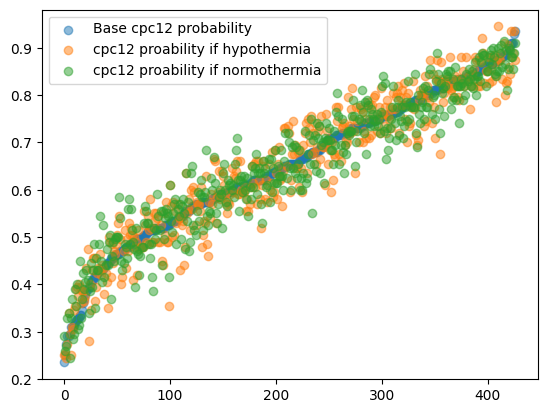

In [31]:
myYPred =  (predicted_probs1 - predicted_probs2)
myYPred = predicted_probs
myDfPreds = pd.DataFrame()

myDfPreds['base'] = predicted_probs
myDfPreds['group1'] = predicted_probs1
myDfPreds['group2'] = predicted_probs2
myDfPreds.sort_values(by=['base'], inplace=True)
plt.scatter(x = range(len(predicted_probs1)), y = myDfPreds['base'], alpha = 0.5)
plt.scatter(x = range(len(predicted_probs1)), y = myDfPreds['group1'], alpha = 0.5)
plt.scatter(x = range(len(predicted_probs1)), y = myDfPreds['group2'], alpha = 0.5)
plt.legend(['Base cpc12 probability', 'cpc12 proability if hypothermia', 'cpc12 proability if normothermia'])


ValueError: cannot insert level_0, already exists

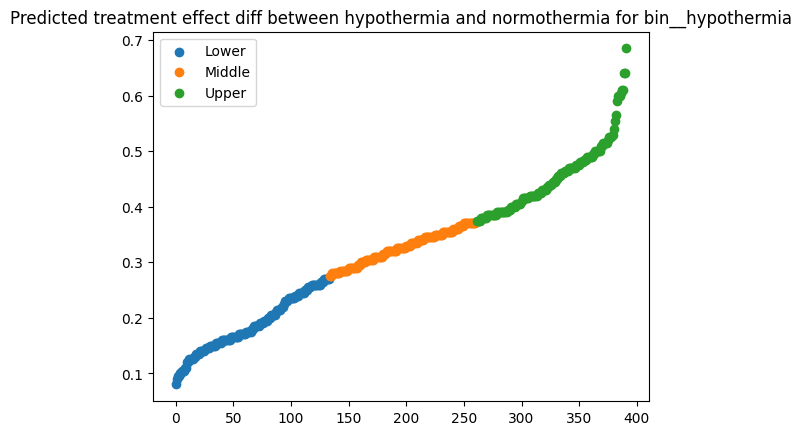

In [32]:
low_third, upper_third, myNewDf = plotPredictedTreatmentEffect(myNewDf, 'bin__hypothermia')
getTreatmentEffectDiffDataFrame(X_train_transf.reset_index(), y_train.reset_index(), myNewDf.reset_index(), 'LastMGCSPositive', 
                                'bin__hypothermia', False)

In [33]:
myNewDf = pd.DataFrame()
myNewDf['predicted_effect'] = myYPred

Optimization terminated successfully.
         Current function value: 0.647481
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.645300
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 1.8630396821688464
p-value: 0.17227438692195765
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:         death_at_disch   No. Observations:                  427
Model:                          Logit   Df Residuals:                      424
Method:                           MLE   Df Model:                            2
Date:                Fri, 03 Apr 2026   Pseudo R-squ.:                0.007603
Time:                        15:22:38   Log-Likelihood:                -276.47
converged:                       True   LL-Null:                       -278.59
Covariance Type:            nonrobust   LLR p-value:                    0.1203
                     

np.float64(0.17227438692195765)

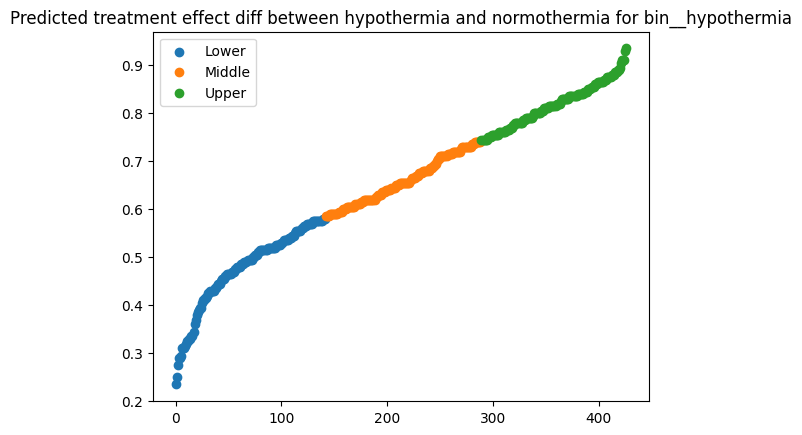

In [34]:
low_third, upper_third, myNewDf = plotPredictedTreatmentEffect(myNewDf, 'bin__hypothermia')
getTreatmentEffectDiffDataFrame(X_train_transf.reset_index(), y_train.reset_index(), myNewDf.reset_index(), 'death_at_disch', 
                                'bin__hypothermia', False)